<a href="https://colab.research.google.com/github/Keke0603/Applied-AI/blob/main/ObjectCount.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics opencv-python matplotlib numpy
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(image_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving Test.jpg to Test.jpg
Test.jpg


Model loaded

0: 384x640 5 cars, 2 trucks, 383.5ms
Speed: 15.1ms preprocess, 383.5ms inference, 48.4ms postprocess per image at shape (1, 3, 384, 640)
Detection done
Model loaded

0: 384x640 5 cars, 2 trucks, 156.6ms
Speed: 7.2ms preprocess, 156.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Detection done
Object count: 7
[(11.15, 9.55), (8.450000000000001, 6.95), (5.7, 4.75), (8.05, 7.65), (8.8, 7.65), (8.05, 7.65), (8.85, 7.65)]


(np.float64(-0.5), np.float64(1139.5), np.float64(654.5), np.float64(-0.5))

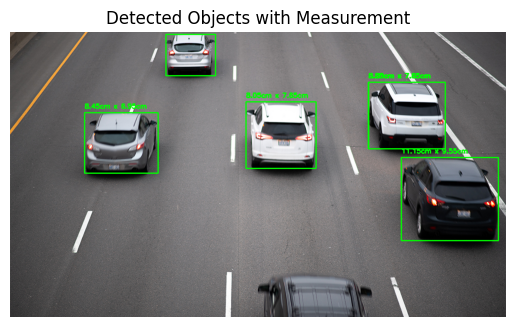

In [4]:
model = YOLO("yolov8n.pt")
print("Model loaded")
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
results = model(image)
boxes = results[0].boxes
print("Detection done")
model = YOLO("yolov8n.pt")
print("Model loaded")
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
results = model(image)
boxes = results[0].boxes
print("Detection done")
count = len(boxes)
print("Object count:", count)
PIXEL_TO_CM = 0.05
measurements = []
output_image = image.copy()

for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    width = x2 - x1
    height = y2 - y1
    width_cm = width * PIXEL_TO_CM
    height_cm = height * PIXEL_TO_CM
    measurements.append((width_cm, height_cm))
    cv2.rectangle(output_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text = f"{width_cm:.2f}cm x {height_cm:.2f}cm"
    cv2.putText(output_image, text, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

print(measurements)
output_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)
plt.imshow(output_rgb)
plt.title("Detected Objects with Measurement")
plt.axis("off")